# Proceso de convolución en imágenes

### 1. Representación de la imagen y el filtro

- Denotemos la **imagen** como una matriz real:
  $$
  I \in \mathbb{R}^{m \times n}
  $$
  donde $m$ es el número de filas (alto) y $n$ es el número de columnas (ancho).

- Denotemos el **filtro (o kernel)** como:
  $$
  K \in \mathbb{R}^{p \times q}
  $$
  donde normalmente $p, q$ son pequeños (por ejemplo, $p=q=3$ para un filtro $3 \times 3$).

---

### 2. Definición de la operación de convolución

La **convolución discreta** entre $I$ y $K$ genera una nueva matriz $O$ (output) donde cada elemento es:
$$
O(i,j) = \sum_{u=0}^{p-1} \sum_{v=0}^{q-1} K(u,v) \cdot I(i+u, j+v)
$$
para cada posición $(i,j)$ donde la operación es válida.

**Notas**:
- Aquí no se está haciendo "flip" del kernel (lo cual técnicamente sería necesario para una convolución pura); en procesamiento de imágenes, frecuentemente se usa directamente el *cross-correlation* en lugar de la convolución matemática estricta.
- Se asume que no hay padding: el tamaño del output será $(m-p+1)\times (n-q+1)$.
- El índice $(i,j)$ recorre solo posiciones donde el filtro cabe completamente sobre la imagen.

---

### 3. Forma alternativa con notación matricial expandida

Cada valor $O(i,j)$ puede verse como el **producto interno** entre:
- el sub-bloque de la imagen $I$ de tamaño $p \times q$ comenzando en $(i,j)$,
- y el filtro \(K\).

Esto se puede expresar como:

$$
O(i,j) = \langle I_{(i:i+p-1, j:j+q-1)}, K \rangle
$$

donde $\langle \cdot, \cdot \rangle$ denota el producto interno de matrices, es decir:

$$
\langle A, B \rangle = \sum_{u,v} A(u,v) B(u,v)
$$

En palabras: **multiplica elemento a elemento y suma todo**.

---

### 4. Ejemplo numérico pequeño

Supongamos:

$$
I = \begin{bmatrix}
1 & 2 & 0 & 1\\
4 & 1 & 2 & 2\\
1 & 3 & 0 & 0\\
2 & 1 & 3 & 1
\end{bmatrix}
\quad
K = \begin{bmatrix}
1 & 0\\
0 & -1
\end{bmatrix}
$$

El primer valor del output sería:

$$
O(0,0) = 1 \cdot 1 + 2 \cdot 0 + 4 \cdot 0 + 1 \cdot (-1) = 1 + 0 + 0 - 1 = 0
$$

Se sigue avanzando desplazando el filtro sobre la imagen.

---

### 5. Resumen final

**Convolución en imágenes** usando notación matricial:

- Imagen: $I \in \mathbb{R}^{m \times n}$
- Filtro: $K \in \mathbb{R}^{p \times q}$
- Output (sin padding): $O \in \mathbb{R}^{(m-p+1) \times (n-q+1)}$
- Operación en cada punto:

$$
O(i,j) = \sum_{u=0}^{p-1} \sum_{v=0}^{q-1} K(u,v) \cdot I(i+u, j+v)
\quad \text{equivalentemente} \quad
O(i,j) = \langle I_{(i:i+p-1, j:j+q-1)}, K \rangle
$$

# Ejemplo de código

1. Cargar una imagen base

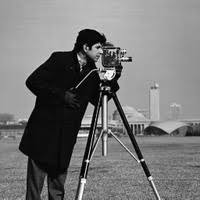

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

image = Image.open("cameraman.jpeg").convert("L")

display(image)

Convertir la imagen a un array numpy

In [2]:
image = np.array(image)
print(image)
print(image.shape)


[[156 156 157 ... 153 153 153]
 [156 156 157 ... 153 153 153]
 [156 156 157 ... 152 152 152]
 ...
 [122 127 106 ... 127 131 123]
 [132 133 130 ... 145 140 116]
 [126 127 149 ... 116 125 118]]
(200, 200)


2. Agregar ruido sal y pimienta

In [3]:
def add_salt_and_pepper_noise(image, amount=0.05, salt_vs_pepper=0.5):
    noisy_image = image.copy()
    num_pixels = int(amount * image.size)
    
    # Sal
    coords = [np.random.randint(0, i - 1, num_pixels) for i in image.shape]
    noisy_image[coords[0], coords[1]] = 255
    
    # Pimienta
    coords = [np.random.randint(0, i - 1, num_pixels) for i in image.shape]
    noisy_image[coords[0], coords[1]] = 0

    return noisy_image

noisy_image = add_salt_and_pepper_noise(image, amount=0.001)

(np.float64(-0.5), np.float64(199.5), np.float64(199.5), np.float64(-0.5))

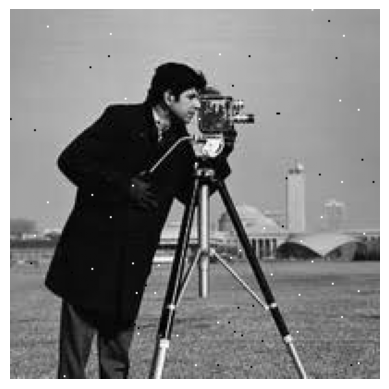

In [4]:
plt.imshow(noisy_image, cmap='gray')
plt.axis('off')

3. Definir un filtro promedio (3x3)

In [5]:
kernel = np.ones((3,3)) / 9

4. Aplicar convolución manual

In [6]:
def convolve(image, kernel):
    m, n = image.shape
    p, q = kernel.shape
    output = np.zeros((m - p + 1, n - q + 1))
    
    for i in range(m - p + 1):
        for j in range(n - q + 1):
            region = image[i:i+p, j:j+q]
            output[i,j] = np.sum(region * kernel)
    
    return output

# Aplicar la convolución
smoothed_image = convolve(noisy_image, kernel)

5. Mostrar las imágenes

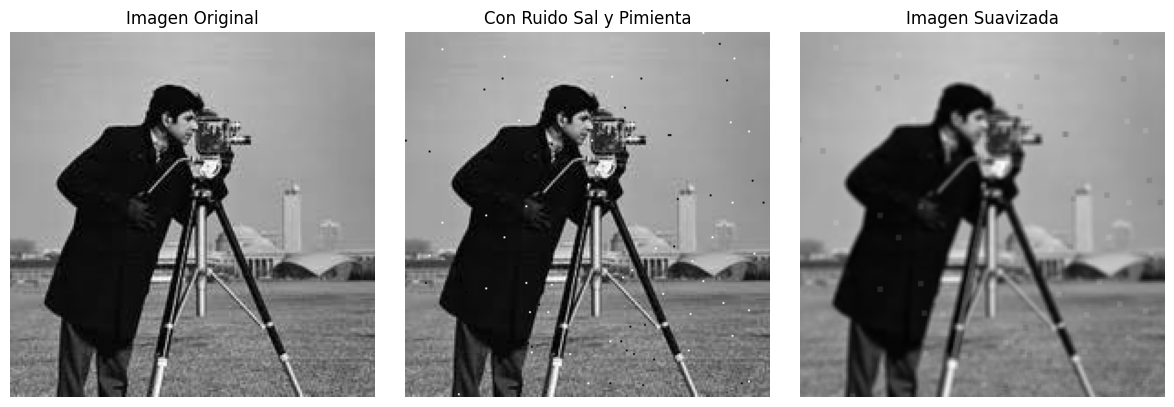

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title('Imagen Original')
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Con Ruido Sal y Pimienta')
plt.imshow(noisy_image, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Imagen Suavizada')
plt.imshow(smoothed_image, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [8]:
# Aplicar la convolución
#smoothed_image = convolve(smoothed_image, kernel)

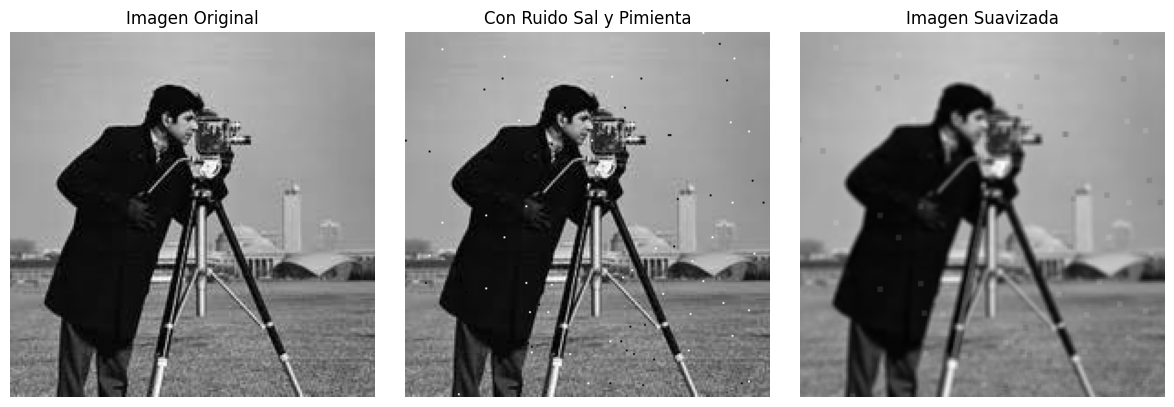

In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title('Imagen Original')
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Con Ruido Sal y Pimienta')
plt.imshow(noisy_image, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Imagen Suavizada')
plt.imshow(smoothed_image, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

### Ejercicio
Revisa el enlace: https://setosa.io/ev/image-kernels/ e implementa un código que aplique los kernels que allí se muestran. Compara el tiempo de ejecución al aplicar la convolución usando una implementación con ciclos *for* versus una implementación con *cv.filter2D* de OpenCV.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from cv2 import filter2D

image = Image.open("cameraman.jpeg").convert("L")
img = np.array(image)

In [11]:
import time

In [12]:
#kernel = np.array([[1, 0, -1],
#                   [1, 0, -1],
#                   [1, 0, -1]])

kernel1 = np.ones((3, 3), dtype=np.float32) / 9

# tiempo de ejecución
#time_start = time.time()
#output_img = filter2D(img, -1, kernel1)
#time_end = time.time()
#print(f"Tiempo de ejecución: {time_end - time_start} segundos")

In [13]:
# tiempo de ejecución de convolución manual
time_start_manual = time.time()
smoothed_image = convolve(img, kernel1)
time_end_manual = time.time()
time_manual = time_end_manual - time_start_manual
print(f"Tiempo de ejecución (convolución manual): {time_manual:.16f} segundos")

# tiempo de ejecución con filtro de OpenCV
time_start_filter2d = time.time()
output_img = filter2D(img, -1, kernel1)
time_end_filter2d = time.time()
time_filter2d = time_end_filter2d - time_start_filter2d
print(f"Tiempo de ejecución (filtro OpenCV): {time_filter2d:.16f} segundos")

Tiempo de ejecución (convolución manual): 0.4795513153076172 segundos
Tiempo de ejecución (filtro OpenCV): 0.0000000000000000 segundos


(np.float64(-0.5), np.float64(197.5), np.float64(197.5), np.float64(-0.5))

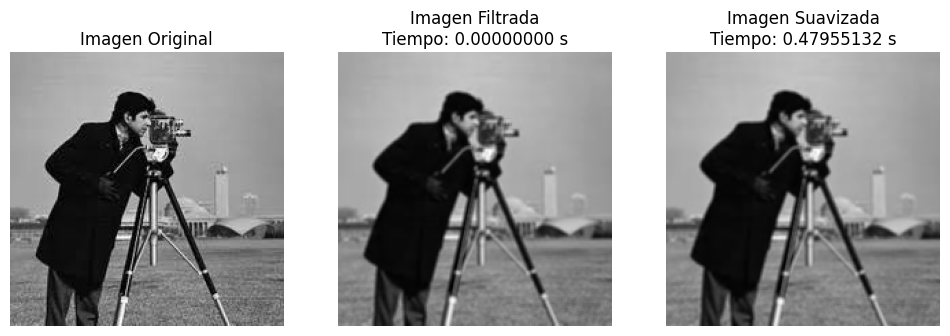

In [14]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title('Imagen Original')
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title(f'Imagen Filtrada\nTiempo: {time_filter2d:.8f} s')
plt.imshow(output_img, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title(f'Imagen Suavizada\nTiempo: {time_manual:.8f} s')
plt.imshow(smoothed_image, cmap='gray')
plt.axis('off')

# Operaciones morfológicas

In [15]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2

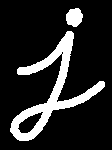

In [16]:
img = Image.open("jota.png").convert("L")
display(img)

(np.float64(-0.5), np.float64(111.5), np.float64(149.5), np.float64(-0.5))

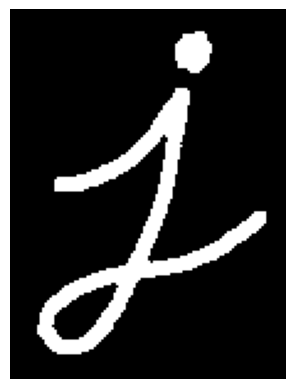

In [17]:
I = np.array(img)
# aplicar erosion
st_elem = np.array([[0, 1, 0],
                     [1, 1, 1],
                     [0, 1, 0]], dtype=np.uint8)
I_erosion = cv2.erode(I, st_elem, iterations=1)
plt.imshow(I_erosion, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(111.5), np.float64(149.5), np.float64(-0.5))

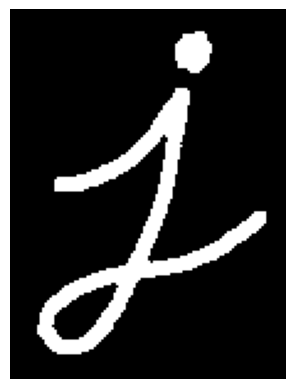

In [18]:
I_erosion = cv2.erode(I, st_elem, iterations=1)
plt.imshow(I_erosion, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(111.5), np.float64(149.5), np.float64(-0.5))

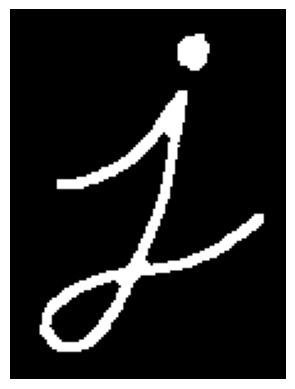

In [19]:
I_erosion = cv2.erode(I_erosion, st_elem, iterations=1)
plt.imshow(I_erosion, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(111.5), np.float64(149.5), np.float64(-0.5))

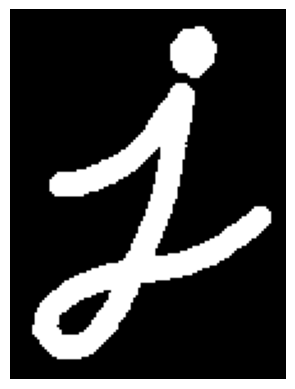

In [20]:
I = np.array(img)
# aplicar dilatacion
st_elem = np.array([[0, 1, 0],
                     [1, 1, 1],
                     [0, 1, 0]], dtype=np.uint8)
I_dilatacion = cv2.dilate(I, st_elem, iterations=1)
plt.imshow(I_dilatacion, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(111.5), np.float64(149.5), np.float64(-0.5))

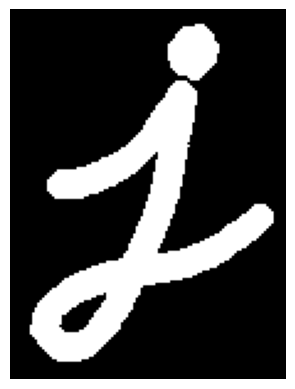

In [21]:
I_dilatacion = cv2.dilate(I_dilatacion, st_elem, iterations=1)
plt.imshow(I_dilatacion, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

(np.float64(-0.5), np.float64(111.5), np.float64(149.5), np.float64(-0.5))

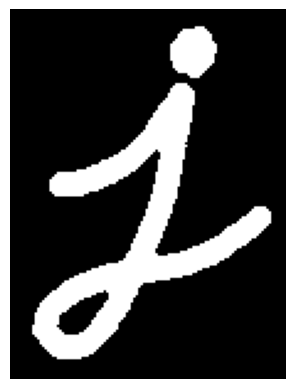

In [22]:
I_erosion = cv2.erode(I_dilatacion, st_elem, iterations=1)
plt.imshow(I_erosion, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(111.5), np.float64(149.5), np.float64(-0.5))

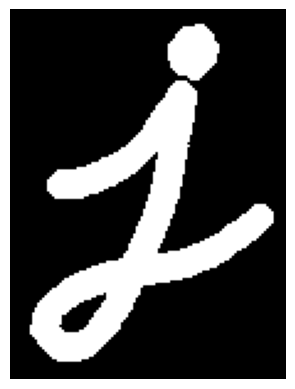

In [23]:
I_dilatacion = cv2.dilate(I_erosion, st_elem, iterations=1)
plt.imshow(I_dilatacion, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(111.5), np.float64(149.5), np.float64(-0.5))

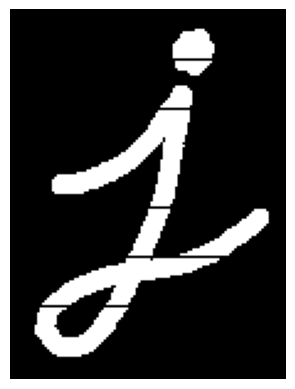

In [24]:
Icopy = I.copy()
Icopy[[20,40,80,100,120],:] = 0
plt.imshow(Icopy, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(111.5), np.float64(149.5), np.float64(-0.5))

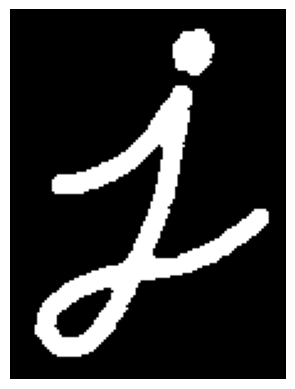

In [25]:
# Operación de cierre closing (dilatación + erosión)
I_dilatacion = cv2.dilate(Icopy, st_elem, iterations=1)
I_cierre = cv2.erode(I_dilatacion, st_elem, iterations=1)
plt.imshow(I_cierre, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(111.5), np.float64(149.5), np.float64(-0.5))

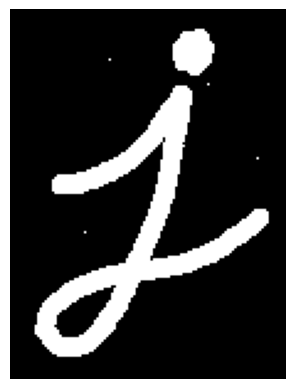

In [26]:
copyI = I.copy()
copyI[20,40] = 255
copyI[90,30] = 255
copyI[30,80] = 255
copyI[60,100] = 255
plt.imshow(copyI, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(111.5), np.float64(149.5), np.float64(-0.5))

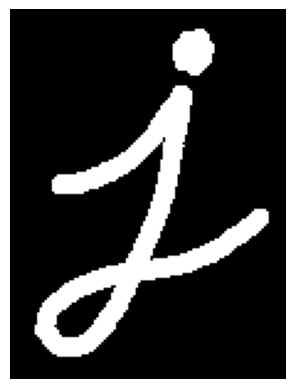

In [27]:
# Operación de apertura opening (erosión + dilatación)
I_erosion = cv2.erode(copyI, st_elem, iterations=1)
I_opening = cv2.dilate(I_erosion, st_elem, iterations=1)
plt.imshow(I_opening, cmap='gray')
plt.axis('off')

In [28]:
import numpy as np

In [ ]:
Iz = np.array([[0, 0, 0, 0, 0],
              [0, 3, -1, 1, 0],
              [0, 2, 0, 2, 0],
              [0, 5, 4, -2, 0],
              [0, 0, 0, 0, 0]])

k2 = np.array([[-3, 1, -1],
               [4, 2, 3],
               [0, 1, 2]])

k3 = np.array([[0, 0, 0],
               [0, 1, 0],
               [0, 0, 0]])

Iout = np.zeros((3, 3))

for i in range(3):
    for j in range(3):
        region = Iz[i:i+3, j:j+3]
        Iout[i, j] = np.sum(region * k3)
 
Iout

array([[ 3., -1.,  1.],
       [ 2.,  0.,  2.],
       [ 5.,  4., -2.]])

In [30]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [31]:
Icam = cv2.imread("cameraman.jpeg", cv2.IMREAD_GRAYSCALE)

In [32]:
Icam.shape

(200, 200)

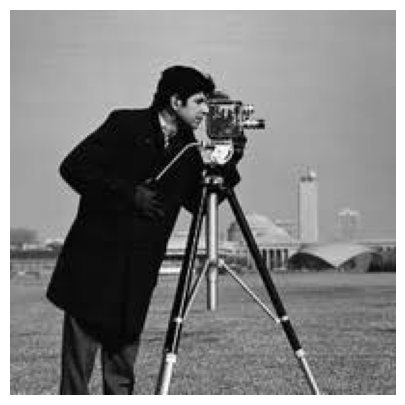

In [33]:
plt.figure(figsize=(10, 5))
plt.axis('off')
plt.imshow(Icam, cmap='gray')

In [34]:
k2 = np.array([[-3, 1, -1],
               [4, 2, 3],
               [0, 1, 2]])

k3 = np.array([[1, 1, 1],
               [0, 0, 0],
               [-1, -1, -1]])

nr, nc = Icam.shape
nor, noc = (nr - k3.shape[0]+1, nc - k3.shape[1]+1)

Iout = np.zeros((nor, noc))

for i in range(nor):
    for j in range(noc):
        region = Icam[i:i+k3.shape[0], j:j+k3.shape[1]]
        Iout[i, j] = np.sum(region * k3)

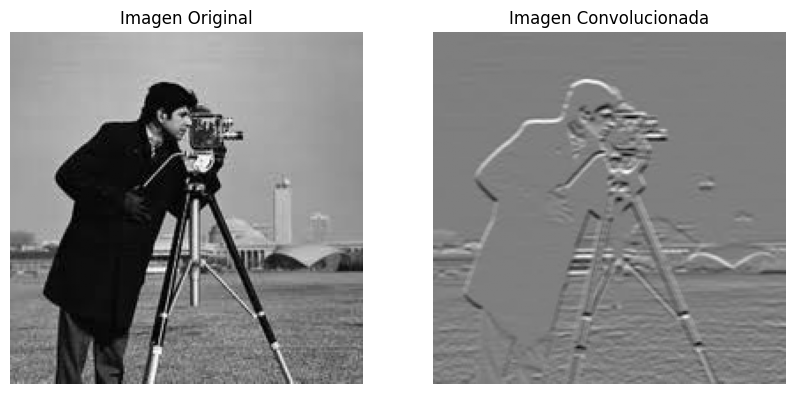

In [35]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Imagen Original')
plt.axis('off')
plt.imshow(Icam, cmap='gray')

plt.subplot(1, 2, 2)
plt.title('Imagen Convolucionada')
plt.axis('off')
plt.imshow(Iout, cmap='gray')

In [36]:
k4 = np.array([[-1, 1, -1],
               [1, 2, 1],
                [-1, 1, -1]])

def miconvolucion(Imag, k):
    nr, nc = Imag.shape
    nor, noc = (nr - k.shape[0]+1, nc - k.shape[1]+1)

    Iout = np.zeros((nor, noc))

    for i in range(nor):
        for j in range(noc):
            region = Imag[i:i+k.shape[0], j:j+k.shape[1]]
            Iout[i, j] = np.sum(region * k)
    return Iout

Iout = miconvolucion(Icam, k4)

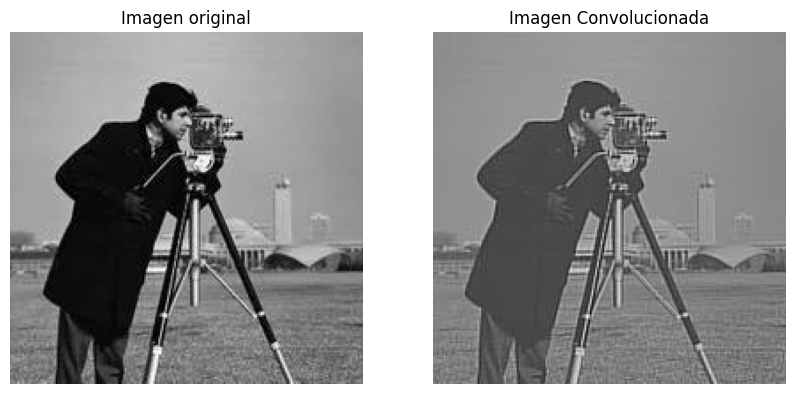

In [37]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Imagen original')
plt.axis('off')
plt.imshow(Icam, cmap='gray')

plt.subplot(1, 2, 2)
plt.title('Imagen Convolucionada')
plt.axis('off')
plt.imshow(Iout, cmap='gray')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-597.0..2564.0].


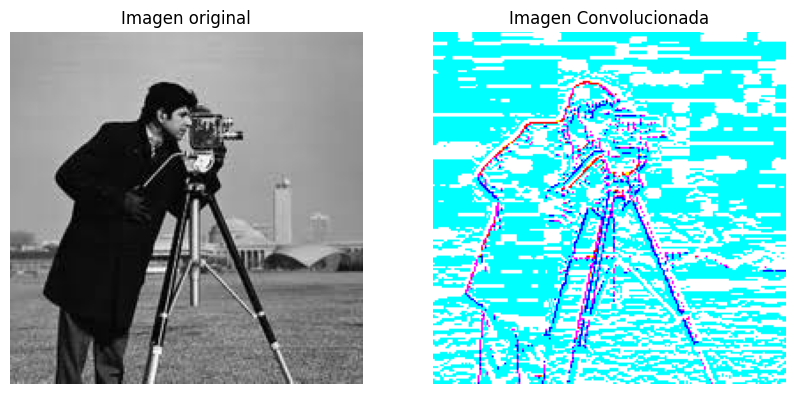

In [38]:
Irgb = cv2.imread("cameraman.jpeg")
Irgb = cv2.cvtColor(Irgb, cv2.COLOR_BGR2RGB)

Ir, Ig, Ib = cv2.split(Irgb)
Ir_out = miconvolucion(Ir, k3)
Ig_out = miconvolucion(Ig, k4)
Ib_out = miconvolucion(Ib, k2)

Irgb_out = cv2.merge((Ir_out, Ig_out, Ib_out))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Imagen original')
plt.axis('off')
plt.imshow(Irgb)

plt.subplot(1, 2, 2)
plt.title('Imagen Convolucionada')
plt.axis('off')
plt.imshow(Irgb_out)

In [39]:
k5 = np.stack((k3, k4, k2))
def miconvolucion(Imag, k):
    nr, nc, np = Imag.shape
    nor, noc, nop = (nr - k.shape[0]+1, nc - k.shape[1]+1, np)

    Iout = np.zeros((nor, noc, nop))

    for i in range(nor):
        for j in range(noc):
            for d in range(nop):
                region = Imag[i:i+k.shape[0], j:j+k.shape[1], d:d+1]
                Iout[i, j, d] = np.sum(region * k[:, :, d])
    return Iout

Iout = miconvolucion(Irgb, k5)

AttributeError: 'int' object has no attribute 'zeros'

In [ ]:
Image1 = Image.open("image1.jpg").convert("L")
Img1 = np.array(Image1)

In [ ]:
# Operación de apertura opening (erosión + dilatación)
I_erosion1 = cv2.erode(Img1, st_elem, iterations=1)
I_opening1 = cv2.dilate(I_erosion1, st_elem, iterations=1)

(np.float64(-0.5), np.float64(325.5), np.float64(312.5), np.float64(-0.5))

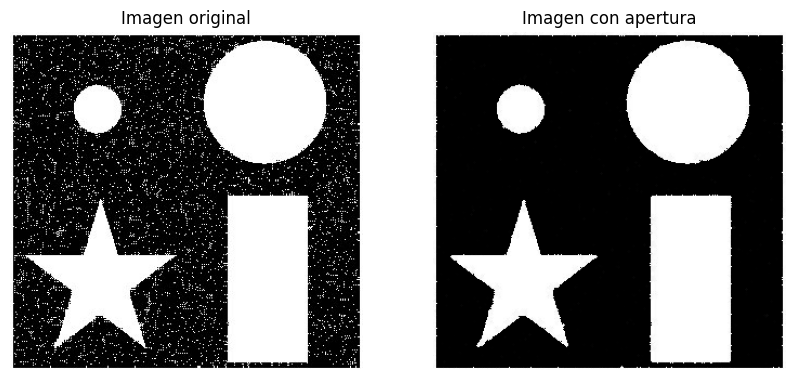

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Imagen original')
plt.imshow(Image1, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Imagen con apertura')
plt.imshow(I_opening1, cmap='gray')
plt.axis('off')

In [41]:
Image2 = Image.open("image2.jpg").convert("L")
Img2 = np.array(Image2)

In [42]:
# Operación de apertura opening (erosión + dilatación)
I_erosion2 = cv2.erode(Img2, st_elem, iterations=1)
I_opening2 = cv2.dilate(I_erosion2, st_elem, iterations=2)

(np.float64(-0.5), np.float64(327.5), np.float64(313.5), np.float64(-0.5))

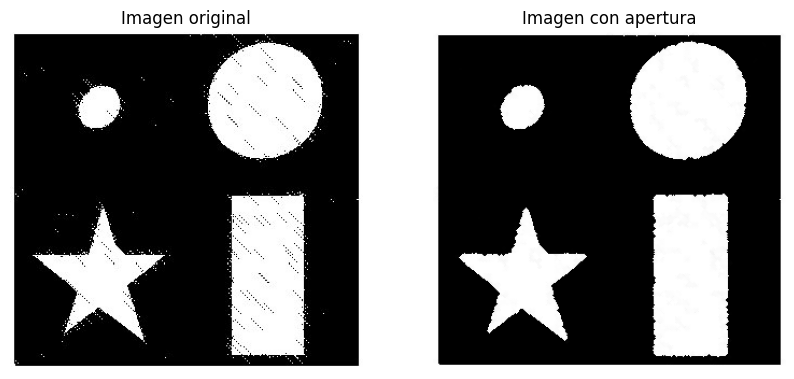

In [43]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Imagen original')
plt.imshow(Image2, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Imagen con apertura')
plt.imshow(I_opening2, cmap='gray')
plt.axis('off')

In [ ]:
I_dilatacion2 = cv2.dilate(I_opening2, st_elem, iterations=1)

(np.float64(-0.5), np.float64(327.5), np.float64(313.5), np.float64(-0.5))

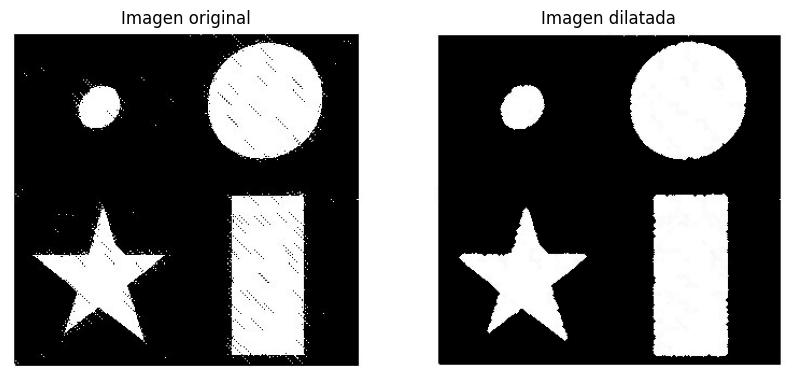

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Imagen original')
plt.imshow(Image2, cmap='gray')
plt.axis('off')  

plt.subplot(1, 2, 2)
plt.title('Imagen dilatada')
plt.imshow(I_dilatacion2, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(4079.5), np.float64(3059.5), np.float64(-0.5))

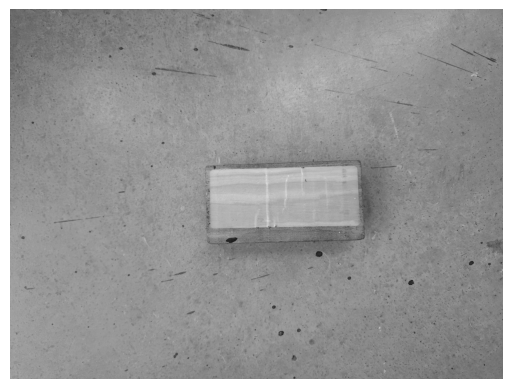

In [207]:
Image3 = cv2.imread("image3.jpg")
Image3_gray = cv2.cvtColor(Image3, cv2.COLOR_BGR2GRAY)

plt.imshow(Image3_gray, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(4079.5), np.float64(3059.5), np.float64(-0.5))

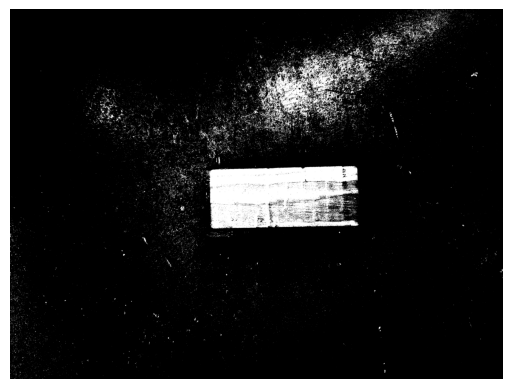

In [208]:
Image3_binary = cv2.threshold(Image3_gray, 165, 200, cv2.THRESH_BINARY)[1]

plt.imshow(Image3_binary, cmap='gray')
plt.axis('off')

In [ ]:
Image3_erosion = cv2.erode(Image3_binary, None, iterations=2)
Image3_dilatacion = cv2.dilate(Image3_erosion, None, iterations=38)

(np.float64(-0.5), np.float64(4079.5), np.float64(3059.5), np.float64(-0.5))

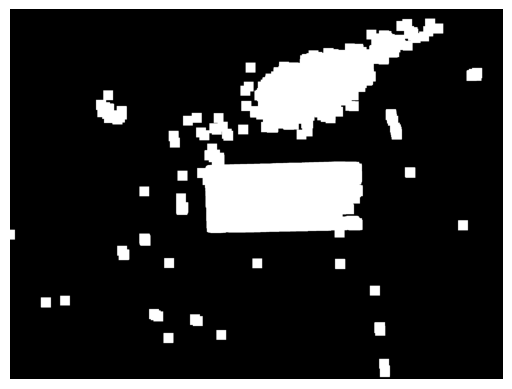

In [212]:
plt.imshow(Image3_dilatacion, cmap='gray')
plt.axis('off')

In [160]:
num_labels, labels_im = cv2.connectedComponents(Image3_dilatacion)